In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Load data
df = pd.read_csv(r'c:\Users\Naomi Bosire\Downloads\K.Codes\Netflix Stock Prices.csv')

# Date handling
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date')

# Feature engineering
df['Volume'] = np.log1p(df['Volume'])
df['Return'] = df['Close'].pct_change()
df['MA10'] = df['Close'].rolling(10).mean()
df['MA50'] = df['Close'].rolling(50).mean()

# Dropping NaNs
df = df.dropna()

C:\Users\Naomi Bosire\AppData\Local\Temp\ipykernel_17268\263719129.py:16: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


In [2]:
features = ['Close', 'Volume', 'MA10', 'MA50', 'Return']
data = df[features]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [3]:
split_ratio = 0.8
split_index = int(len(scaled_data) * split_ratio)

train_data = scaled_data[:split_index]
test_data = scaled_data[split_index:]

In [4]:
sequence_length = 60
batch_size = 32

train_generator = TimeseriesGenerator(
    train_data, train_data[:, 0],  # predicting Close only
    length=sequence_length,
    batch_size=batch_size
)

test_generator = TimeseriesGenerator(
    test_data, test_data[:, 0],
    length=sequence_length,
    batch_size=1
)

In [5]:
model = Sequential()

model.add(LSTM(256, return_sequences=True, input_shape=(sequence_length, len(features))))
model.add(Dropout(0.2))

model.add(LSTM(128))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mae')

c:\Users\Naomi Bosire\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    verbose=1
)

predictions_scaled = model.predict(test_generator)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 45s 536ms/step - loss: 0.1448 - val_loss: 0.2491
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 536ms/step - loss: 0.0947 - val_loss: 0.1263
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 539ms/step - loss: 0.0611 - val_loss: 0.0410
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 502ms/step - loss: 0.0557 - val_loss: 0.0921
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 526ms/step - loss: 0.0547 - val_loss: 0.0568
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 740ms/step - loss: 0.0384 - val_loss: 0.0764
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 510ms/step - loss: 0.0702 - val_loss: 0.0382
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 473ms/step - loss: 0.0518 - val_loss: 0.0909
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 483ms/step - loss: 0.0451 - val_loss: 0.0396
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 481ms/step - loss: 0.0501 - val_loss: 0.0840
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 468ms/step - loss: 0.0407 - val_loss: 0.0389
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11

In [7]:
# Creating dummy array to inverse transform
dummy = np.zeros((len(predictions_scaled), len(features)))
dummy[:, 0] = predictions_scaled[:, 0]

predicted_prices = scaler.inverse_transform(dummy)[:, 0]

# Actual prices
actual = test_data[sequence_length:, 0]

dummy_actual = np.zeros((len(actual), len(features)))
dummy_actual[:, 0] = actual

actual_prices = scaler.inverse_transform(dummy_actual)[:, 0]

In [8]:
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
print("RMSE:", rmse)

RMSE: 10.948502905155166


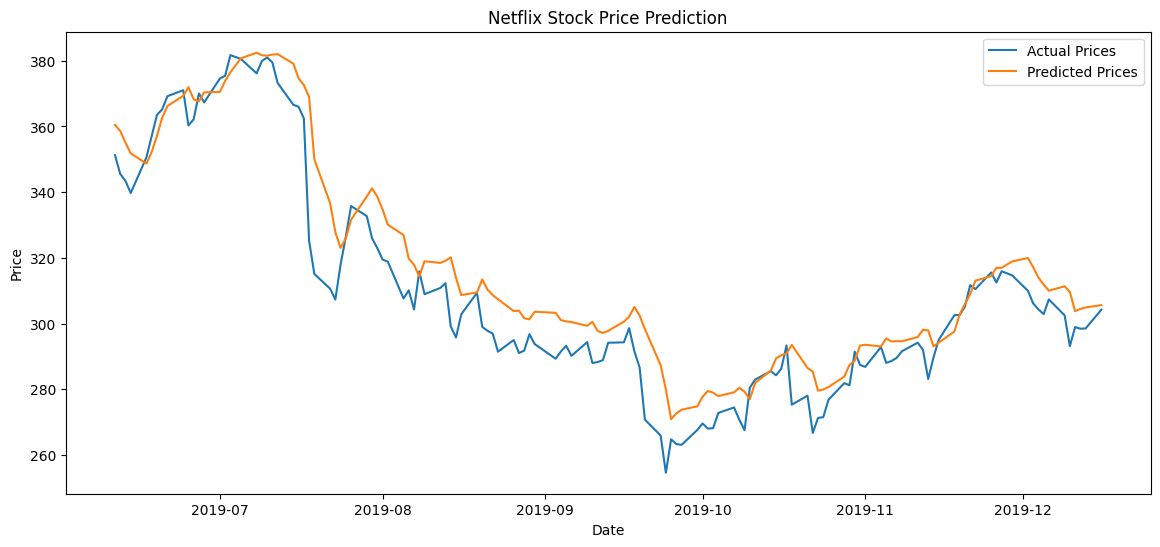

In [9]:
test_dates = df['Date'][split_index + sequence_length:]

plt.figure(figsize=(14,6))

plt.plot(test_dates, actual_prices, label='Actual Prices')
plt.plot(test_dates, predicted_prices, label='Predicted Prices')

plt.title('Netflix Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()

In [10]:
import joblib

model.save("model.h5")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from flask import Flask, request, jsonify
import numpy as np
import joblib
from tensorflow.keras.models import load_model

app = Flask(__name__)

# LOAD MODEL + SCALER
model = load_model("model.h5", compile=False)

scaler = joblib.load("scaler.pkl")

# must match training window size
WINDOW_SIZE = 60

# ROUTES
# prediction

@app.route("/")
def home():
    return "LSTM API is running 🚀"


@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json()

        prices = np.array(data["prices"]).reshape(-1, 1)

        # give model enough history
        if len(prices) < WINDOW_SIZE:
            return jsonify({
                "error": f"Need at least {WINDOW_SIZE} values"
            })

        # converts to real prices
        scaled = scaler.transform(prices)

        # LSTM expects(samples, time_steps, features) 
        X_input = scaled[-WINDOW_SIZE:].reshape(1, WINDOW_SIZE, 1)

        # predict
        pred_scaled = model.predict(X_input)

        # inverse transform
        prediction = scaler.inverse_transform(pred_scaled)

        return jsonify({
            "prediction": float(prediction[0][0])
        })

    except Exception as e:
        return jsonify({
            "error": str(e)
        })

# RUN SERVER
if __name__ == "__main__":
    # FIX: prevents Jupyter / auto-reloader crash
    app.run(debug=True, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [21/Apr/2026 09:12:34] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Apr/2026 09:12:35] "GET /favicon.ico HTTP/1.1" 404 -
